# Level 2 - Task 1

## Table Booking and Online Delivery Analysis

### Objective
The objective of this task is to:
- Determine the percentage of restaurants offering table booking.
- Determine the percentage of restaurants offering online delivery.
- Compare average ratings of restaurants with and without table booking.
- Analyze online delivery availability across different price ranges.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('default')

In [2]:
df = pd.read_csv("Dataset .csv")

In [3]:
print("Dataset Shape:", df.shape)

df.head()

Dataset Shape: (9551, 21)


,Restaurant ID,Restaurant Name,Country Code,City,Address,Locality,Locality Verbose,Longitude,Latitude,Cuisines,...,Currency,Has Table booking,Has Online delivery,Is delivering now,Switch to order menu,Price range,Aggregate rating,Rating color,Rating text,Votes
0,6317637,Le Petit Souffle,162,Makati City,"Third Floor, Century City Mall, Kalayaan Avenu...","Century City Mall, Poblacion, Makati City","Century City Mall, Poblacion, Makati City, Mak...",121.027535,14.565443,"French, Japanese, Desserts",...,Botswana Pula(P),Yes,No,No,No,3,4.8,Dark Green,Excellent,314
1,6304287,Izakaya Kikufuji,162,Makati City,"Little Tokyo, 2277 Chino Roces Avenue, Legaspi...","Little Tokyo, Legaspi Village, Makati City","Little Tokyo, Legaspi Village, Makati City, Ma...",121.014101,14.553708,Japanese,...,Botswana Pula(P),Yes,No,No,No,3,4.5,Dark Green,Excellent,591
2,6300002,Heat - Edsa Shangri-La,162,Mandaluyong City,"Edsa Shangri-La, 1 Garden Way, Ortigas, Mandal...","Edsa Shangri-La, Ortigas, Mandaluyong City","Edsa Shangri-La, Ortigas, Mandaluyong City, Ma...",121.056831,14.581404,"Seafood, Asian, Filipino, Indian",...,Botswana Pula(P),Yes,No,No,No,4,4.4,Green,Very Good,270
3,6318506,Ooma,162,Mandaluyong City,"Third Floor, Mega Fashion Hall, SM Megamall, O...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.056475,14.585318,"Japanese, Sushi",...,Botswana Pula(P),No,No,No,No,4,4.9,Dark Green,Excellent,365
4,6314302,Sambo Kojin,162,Mandaluyong City,"Third Floor, Mega Atrium, SM Megamall, Ortigas...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.057508,14.584450,"Japanese, Korean",...,Botswana Pula(P),Yes,No,No,No,4,4.8,Dark Green,Excellent,229


## Dataset Overview

This dataset contains restaurant information such as:

- Restaurant Name
- Location
- Cuisines
- Aggregate Rating
- Price Range
- Online Delivery
- Table Booking

The dataset consists of 9551 restaurant records and 21 attributes.

The objective of this analysis is to explore customer convenience features, pricing trends, and perform feature engineering for future machine learning applications.

# Task 1: Table Booking and Online Delivery Analysis

### Objective

- Determine the percentage of restaurants offering table booking.
- Determine the percentage of restaurants offering online delivery.
- Compare average ratings of restaurants with and without table booking.
- Analyze online delivery availability across different price ranges.

In [4]:
table_booking_percentage = (
    df["Has Table booking"]
    .value_counts(normalize=True) * 100
)

print(table_booking_percentage)

Has Table booking
No     87.875615
Yes    12.124385
Name: proportion, dtype: float64


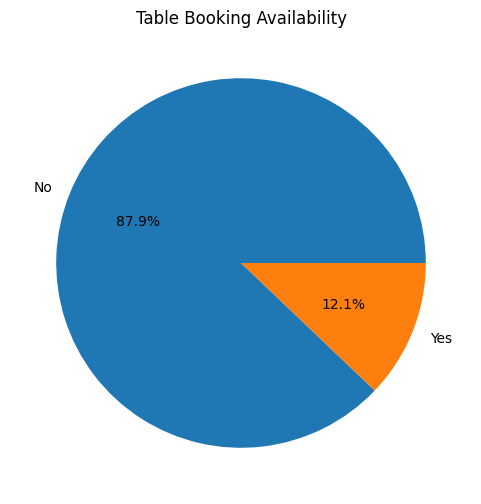

In [5]:
plt.figure(figsize=(6,6))

df["Has Table booking"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%"
)

plt.title("Table Booking Availability")
plt.ylabel("")
plt.show()

### Observation

- The majority of restaurants do not offer table booking.
- Only a smaller portion of restaurants provide table reservation facilities.
- Table booking appears to be a premium feature offered by selected restaurants.

In [6]:
online_delivery_percentage = (
    df["Has Online delivery"]
    .value_counts(normalize=True) * 100
)

print(online_delivery_percentage)

Has Online delivery
No     74.337766
Yes    25.662234
Name: proportion, dtype: float64


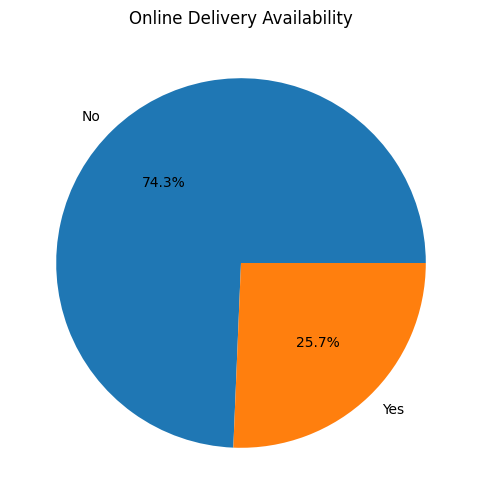

In [7]:
plt.figure(figsize=(6,6))

df["Has Online delivery"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%"
)

plt.title("Online Delivery Availability")
plt.ylabel("")
plt.show()

### Observation

- Online delivery is available in a significant number of restaurants.
- Many restaurants still operate without delivery services.
- Online delivery has become an important customer convenience feature.

In [8]:
avg_rating_booking = (
    df.groupby("Has Table booking")
      ["Aggregate rating"]
      .mean()
)

print(avg_rating_booking)

Has Table booking
No     2.559359
Yes    3.441969
Name: Aggregate rating, dtype: float64


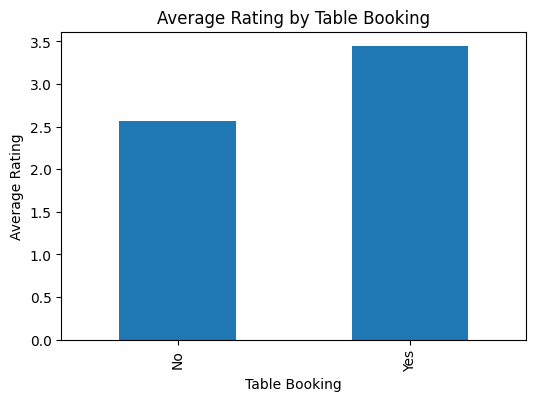

In [9]:
avg_rating_booking.plot(
    kind="bar",
    figsize=(6,4)
)

plt.title("Average Rating by Table Booking")
plt.xlabel("Table Booking")
plt.ylabel("Average Rating")

plt.show()

### Observation

- Restaurants offering table booking generally have different average ratings compared to those without table booking.
- The comparison suggests that customer convenience features may influence customer satisfaction.

In [10]:
delivery_price = pd.crosstab(
    df["Price range"],
    df["Has Online delivery"]
)

print(delivery_price)

Has Online delivery    No   Yes
Price range                    
1                    3743   701
2                    1827  1286
3                     997   411
4                     533    53


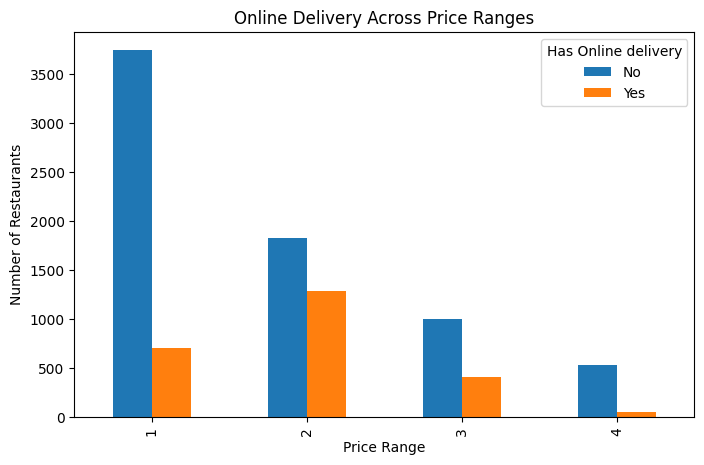

In [11]:
delivery_price.plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Online Delivery Across Price Ranges")
plt.xlabel("Price Range")
plt.ylabel("Number of Restaurants")

plt.show()

### Observation

- Online delivery availability varies across different price ranges.
- Lower and medium-priced restaurants appear to focus more on delivery services.
- Customer convenience services differ across restaurant segments.

# Task 2: Price Range Analysis

### Objectives
- Determine most common price range.
- Calculate average ratings for each price range.
- Identify rating colors associated with price ranges.


---

## Most Common Price Range

```python
price_range_counts = df["Price range"].value_counts()

print(price_range_counts)

Price range
1    4444
2    3113
3    1408
4     586
Name: count, dtype: int64


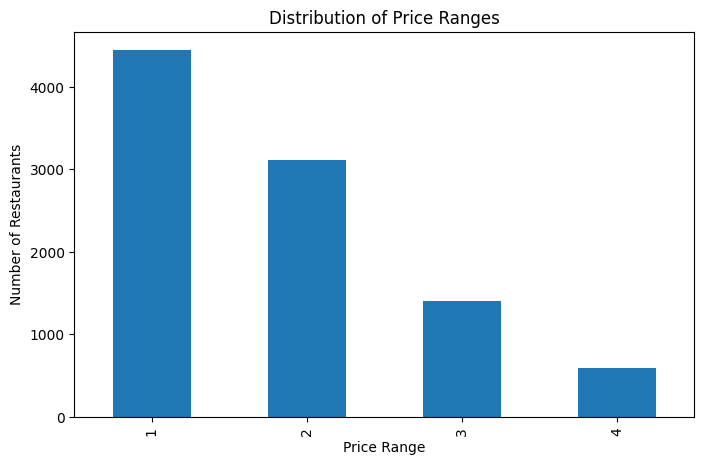

In [12]:
price_range_counts = df["Price range"].value_counts()
print(price_range_counts)
price_range_counts.plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Distribution of Price Ranges")
plt.xlabel("Price Range")
plt.ylabel("Number of Restaurants")

plt.show()

### Observation

- Certain price ranges dominate the dataset.
- Most restaurants fall within affordable and mid-range categories.
- Higher price ranges represent a smaller proportion of restaurants.

In [13]:
avg_price_rating = (
    df.groupby("Price range")
      ["Aggregate rating"]
      .mean()
)

print(avg_price_rating)

Price range
1    1.999887
2    2.941054
3    3.683381
4    3.817918
Name: Aggregate rating, dtype: float64


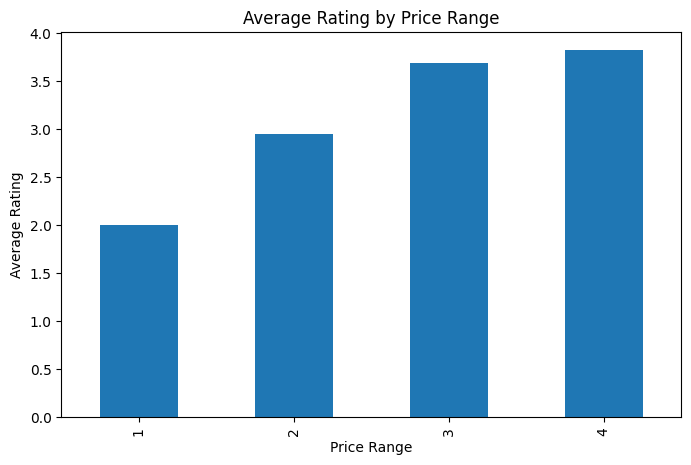

In [14]:
avg_price_rating.plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Average Rating by Price Range")
plt.xlabel("Price Range")
plt.ylabel("Average Rating")

plt.show()

### Observation

- Average ratings differ across price ranges.
- Restaurant pricing appears to have some relationship with customer ratings.
- Higher-priced restaurants may provide enhanced dining experiences.

In [15]:
rating_color_analysis = (
    df.groupby("Rating color")
      ["Aggregate rating"]
      .mean()
      .sort_values(ascending=False)
)

print(rating_color_analysis)

Rating color
Dark Green    4.659801
Green         4.168119
Yellow        3.683429
Orange        3.051619
Red           2.297849
White         0.000000
Name: Aggregate rating, dtype: float64


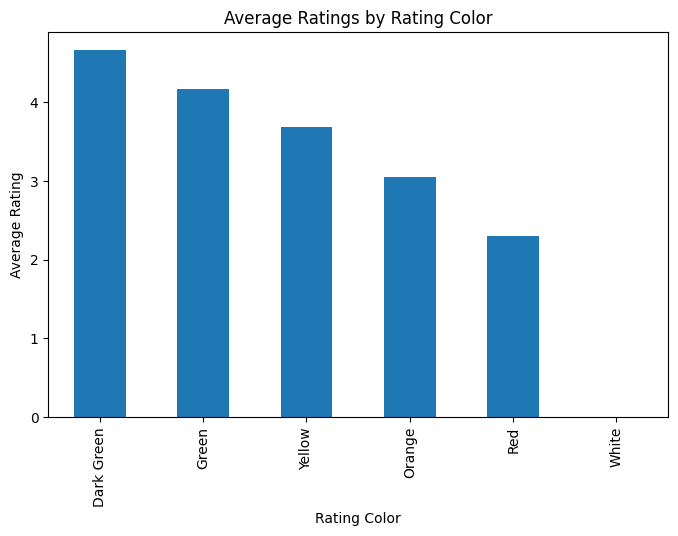

In [16]:
rating_color_analysis.plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Average Ratings by Rating Color")
plt.xlabel("Rating Color")
plt.ylabel("Average Rating")

plt.show()

### Observation

- Rating colors successfully represent rating categories.
- Certain rating colors are associated with higher average ratings.
- Rating color provides a quick visual indication of restaurant performance.

# Task 3: Feature Engineering

### Objectives
- Create additional features.
- Transform categorical variables.
- Prepare data for machine learning.

In [17]:
df["Restaurant_Name_Length"] = (
    df["Restaurant Name"]
    .str.len()
)

In [18]:
df["Address_Length"] = (
    df["Address"]
    .str.len()
)

In [19]:
df["Has_Table_Booking"] = (
    df["Has Table booking"]
    .map({"Yes":1,"No":0})
)

In [20]:
df["Has_Online_Delivery"] = (
    df["Has Online delivery"]
    .map({"Yes":1,"No":0})
)

In [21]:
df[
    [
        "Restaurant Name",
        "Restaurant_Name_Length",
        "Address_Length",
        "Has_Table_Booking",
        "Has_Online_Delivery"
    ]
].head()

,Restaurant Name,Restaurant_Name_Length,Address_Length,Has_Table_Booking,Has_Online_Delivery
0,Le Petit Souffle,16,71,1,0
1,Izakaya Kikufuji,16,67,1,0
2,Heat - Edsa Shangri-La,22,56,1,0
3,Ooma,4,70,0,0
4,Sambo Kojin,11,64,1,0


In [22]:
df[
[
"Restaurant_Name_Length",
"Address_Length",
"Has_Table_Booking",
"Has_Online_Delivery"
]
].describe()

,Restaurant_Name_Length,Address_Length,Has_Table_Booking,Has_Online_Delivery
count,9551.000000,9551.000000,9551.000000,9551.000000
mean,15.164171,53.536698,0.121244,0.256622
std,6.858392,17.122035,0.326428,0.436792
min,2.000000,13.000000,0.000000,0.000000
25%,10.000000,41.000000,0.000000,0.000000
50%,14.000000,52.000000,0.000000,0.000000
75%,19.000000,64.000000,0.000000,1.000000
max,54.000000,132.000000,1.000000,1.000000


### Observation

- New numerical features were successfully created.
- Restaurant name and address lengths provide additional information for analysis.
- Categorical variables were converted into numerical format for machine learning compatibility.

In [23]:
new_features = df[
    [
        "Restaurant_Name_Length",
        "Address_Length",
        "Has_Table_Booking",
        "Has_Online_Delivery",
        "Aggregate rating"
    ]
]

new_features.corr()

,Restaurant_Name_Length,Address_Length,Has_Table_Booking,Has_Online_Delivery,Aggregate rating
Restaurant_Name_Length,1.000000,0.009567,0.075672,-0.159614,-0.035178
Address_Length,0.009567,1.000000,0.064177,-0.018362,0.002334
Has_Table_Booking,0.075672,0.064177,1.000000,0.101224,0.189998
Has_Online_Delivery,-0.159614,-0.018362,0.101224,1.000000,0.225699
Aggregate rating,-0.035178,0.002334,0.189998,0.225699,1.000000


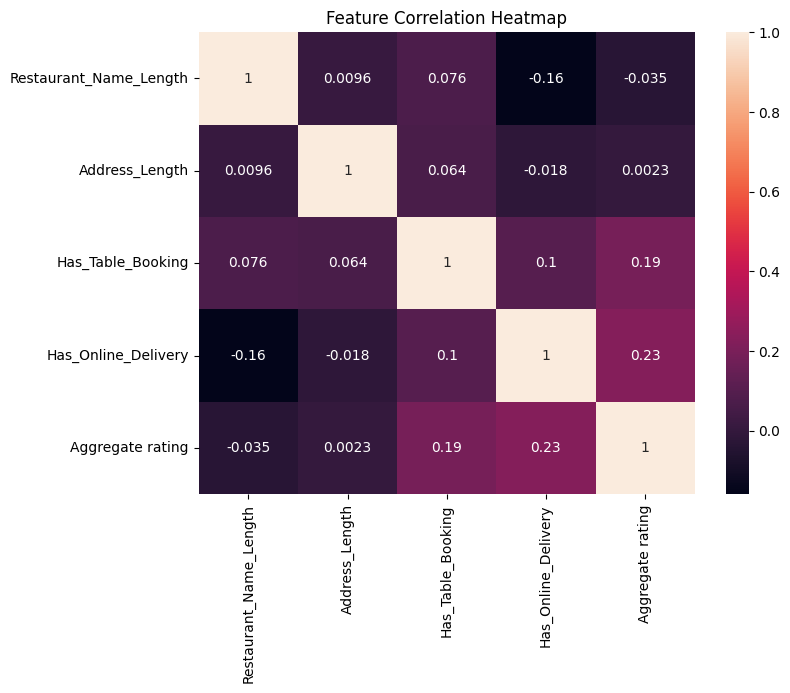

In [24]:
plt.figure(figsize=(8,6))

sns.heatmap(
    new_features.corr(),
    annot=True
)

plt.title("Feature Correlation Heatmap")
plt.show()

### Observation

- The correlation matrix helps identify relationships among engineered features.
- Some features show weak correlation with restaurant ratings.
- These engineered features may be useful for future predictive modeling tasks.

# Conclusion

This project successfully completed all Level 2 tasks of the Cognifyz Data Science Internship.

Key findings include:

- Analysis of table booking and online delivery services.
- Exploration of restaurant pricing trends.
- Comparison of ratings across different restaurant categories.
- Creation of new engineered features for future machine learning applications.

The project provided practical experience in exploratory data analysis, visualization, feature engineering, and business insight generation using real-world restaurant data.

# Thank You

This notebook was created as part of the Cognifyz Data Science Internship Program.

Tools Used:
- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn

Skills Demonstrated:
- Business Data Analysis
- Feature Engineering
- Statistical Analysis
- Data Visualization
- Data Preprocessing